In this workbook we show an example application of the entire workflow presented in this repository. 

In this workbook we will
- Analyze an example of AOD retrieval gaps.
- Apply our pre-trained gap-filling model.
- Use pre-trained random forest to relate satellite AOD to ground level PM2.5.

First we will import essential libraries and define data paths!

In [52]:
import os
import sys
import numpy as np
import pandas as pd
import rasterio as rio
import time
import tensorflow as tf
import re
import xarray as xr
import rioxarray
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from skimage import io as skio
from skimage import util as skutil
from matplotlib import pyplot as plt
# Import modules from lib/ directory
from lib.STpconvUnet import STpconvUnet
from lib.DataGenerator import DataGenerator

import gc
import sys


from scipy.ndimage import gaussian_filter
DEMO_DATA_DIR = "/Volumes/External/data/pm_demo_data"
DATA_PATH_OUT = "/opt/projects/demo_pm25/outdata"
model2 = STpconvUnet.load("model_architecture_MERRA2_36_test22norm500",
                          weights_name="out_MERRA2_36_test22norm500/epoch_05.h5")


Now let's define some important functions. These functions will be essential for smoothing outputs from successive runs and defining a threshold for which to accept predictions from the gap-filling model.

In [53]:

def smooth_transitions(existing, predicted, mask, sigma=2):
    """
    Smooths the transitions between existing and predicted values using Gaussian blurring.

    :param existing: Original image with existing values.
    :param predicted: Image with predicted values.
    :param mask: Binary mask indicating missing values (0 for missing, 1 for existing).
    :param sigma: Standard deviation for Gaussian kernel.
    :return: Smoothed image.
    """
    combined = existing.copy()
    combined[mask == 0] = predicted[mask == 0]

    blurred = gaussian_filter(combined, sigma=sigma)
    blurred[predicted == pred_const] = -3.4e+38
    smoothed = existing * mask + blurred * (1 - mask)
    return smoothed


def predict_single_overlap(input_dt, sub_itert, n):
    temp = input_dt.values.transpose(1, 2, 0)
    temp = temp/5
    temp = np.expand_dims(temp, axis=0)  # append "sample" dimension
    temp = np.expand_dims(temp, axis=4)  # append "channel" dimension
    temp[temp < 0] = 0
    X = temp.copy()

    mask = temp.copy()
    mask[mask != 0] = 1

    # 2nd mask is not needed here, so we simply use the same mask
    pred = model2.predict([X, mask, mask])
    pred = np.clip(pred, a_min=0, a_max=1.0)  # set the upper limit to 5
    # pred[pred == pred_const] = -3.4e+38 / 5
    # pred[X > 0] = X[X > 0]
    pred = smooth_transitions(X, pred, mask, sigma=2)
    pred = pred*5

    # create output file and copy spatial reference from input
    # input_dt.values[:] = pred[0,:,:,:,0].transpose(2,0,1)
    pred = pred[0, :, :, :, 0].transpose(2, 0, 1)
    sub_itert.values[(input_dt.values < 0) & (pred > 0)] = n+1
    input_dt.values[input_dt.values < 0] = pred[input_dt.values < 0]

    return input_dt, sub_itert

def sort_by_number(file_name):
    # Extract the second number from the file name
    # Assuming the file names are like "prefix_number1_number2_suffix"
    file_number = int(re.split(r'[_.]', file_name)[3])
    return file_number

Now let's load in the datafiles. The gap-filling model takes three dimensional inputs so we will need to load in 36 hours of GOES AOD data as an input to our model.

In [54]:
tif_paths = [
    f"{DEMO_DATA_DIR+'/GOES16_0.02'}_{j}.tif" for j in range(1104, 1140)]
arrays = [rioxarray.open_rasterio(
    tif_path).fillna(-3.4e+38) for tif_path in tif_paths]
input_data = xr.concat(arrays, dim='band')
# remove AOD lower than MERRA2 min
input_data = input_data.where(input_data >= 0.007162074, other=-3.4e+38)
# remove AOD higher than 5 updated on May 21, 2024
input_data = input_data.where(input_data < 5, other=-3.4e+38)
input_data['band'] = np.arange(1, 37)
input_data['x'] = input_data.x.round(2)
input_data['y'] = input_data.y.round(2)
iter_times = input_data.copy()
iter_times = iter_times.where(iter_times <= 0, 0)

Let's visualize a single hourly input to highlight the retreival gaps. We'll visualize T-36 as that timestamp had a particularly robust retrieval.

/var/folders/d_/4hv15k7s6xd_m65h26npp7d40000gn/T/ipykernel_55248/17794953.py:9: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


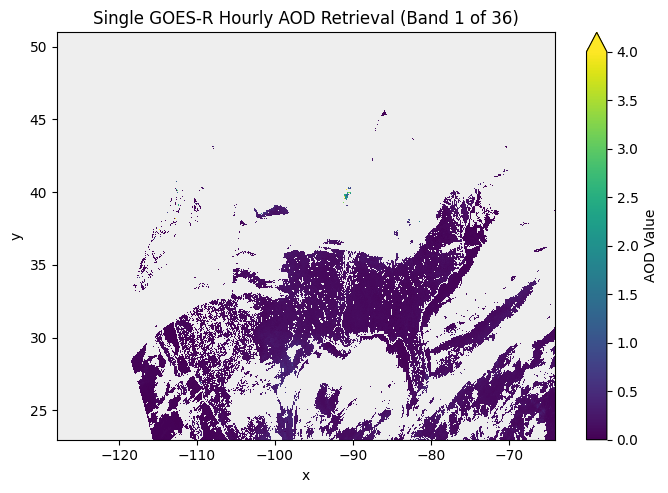

In [55]:
slices_to_plot = input_data.isel(band=slice(35, 36))
masked_data = slices_to_plot.where(slices_to_plot > 0)
g = masked_data.plot(
    x="x", y="y", col="band", col_wrap=1, 
    cmap="viridis", vmin=0, vmax=4, # AOD usually sits in this range
    figsize=(7, 5),
    cbar_kwargs={'label': 'AOD Value'}
)
for ax in g.axes.flat:
    ax.set_title(f"Single GOES-R Hourly AOD Retrieval (Band 1 of 36)")
    ax.set_facecolor('#eeeeee') # Light grey background to highlight the "holes"
plt.show()

We iteratively gap-fill subdomains across the CONUS. This process is very computationally intensive so we will apply the gap-filling model to a single subdomain. To identify which subdomain to use, we will chose the subdomina with the lowest missing ratio.

In [56]:
missing_ratio = pd.DataFrame(columns=[0, 1, 2, 3, 4])
for r in range(4):
    for c in range(5):
        sub_tmp = input_data[:, 300 *
                                r:(500+300*r), 600*c:(800+600*c)].copy()
        missing_ratio.loc[r, c] = np.count_nonzero(
            sub_tmp == -3.4e+38)/36/500/800
df_b = missing_ratio.stack().reset_index()
df_b.columns = ['Row Index', 'Column Name', 'Sorted Values']
df_b.sort_values('Sorted Values', inplace=True)
df_b.reset_index(drop=True, inplace=True)
missing_ratio.head()

,0,1,2,3,4
0,0.932661,0.809506,0.816352,0.877602,0.79709
1,0.973441,0.894227,0.826764,0.920545,0.917694
2,0.987421,0.972277,0.950563,0.986511,0.986215
3,0.9992,0.999834,0.999634,0.999673,0.999879


In [57]:
import gc
import time

start = time.process_time()
n = 0
X_warm, M_warm = np.zeros([1, 500, 800, 36, 1]), np.zeros([1, 500, 800, 36, 1])
pred_warm = model2.predict([X_warm, M_warm, M_warm], verbose=0)
pred_const = pred_warm[0, 0, 0, 0, 0]

# Target and its neighbors (3x3 grid)
target_r, target_c = 1, 2
neighborhood = [(r, c) for r in range(target_r-1, target_r+2) 
                       for c in range(target_c-1, target_c+2) 
                       if 0 <= r < 4 and 0 <= c < 5]

max_iterations = 3
num_iterations = 0

while num_iterations < max_iterations:
    print(f"--- Iteration {num_iterations + 1} ---")
    for r, c in neighborhood:
        y_s, x_s = slice(300*r, 500+300*r), slice(600*c, 800+600*c)
        sub_input, sub_itert = input_data[:, y_s, x_s], iter_times[:, y_s, x_s]
        
        # Track filling only for the central target block
        if r == target_r and c == target_c:
            gaps_before = np.count_nonzero(sub_input[12:].values <= -3e+38)
            predict_single_overlap(sub_input, sub_itert, n)
            gaps_after = np.count_nonzero(sub_input[12:].values <= -3e+38)
            print(f"Target R{r}C{c} | Gaps filled: {gaps_before - gaps_after}")
        else:
            predict_single_overlap(sub_input, sub_itert, n)
        gc.collect()
    n += 1
    num_iterations += 1

t = time.process_time() - start
y_s, x_s = slice(300*target_r, 500+300*target_r), slice(600*target_c, 800+600*target_c)
final_sub_input, final_sub_itert = input_data[12:, y_s, x_s], iter_times[12:, y_s, x_s]

final_sub_input.rio.to_raster(f"{DATA_PATH_OUT}/PRED_36.tif")
final_sub_itert.rio.to_raster(f"{DATA_PATH_OUT}/Iter_times_36.tif")
print(f"DONE. Total time: {t:.2f}s. Files saved for Target Subdomain with Neighbor Context.")

--- Iteration 1 ---
1/1 [==============================] - 11s 11s/step
Target R1C2 | Gaps filled: 413658
1/1 [==============================] - 11s 11s/step
--- Iteration 2 ---
1/1 [==============================] - 11s 11s/step
Target R1C2 | Gaps filled: 43499
1/1 [==============================] - 10s 10s/step
--- Iteration 3 ---
1/1 [==============================] - 11s 11s/step
Target R1C2 | Gaps filled: 698
1/1 [==============================] - 12s 12s/step
DONE. Total time: 1654.49s. Files saved for Target Subdomain with Neighbor Context.


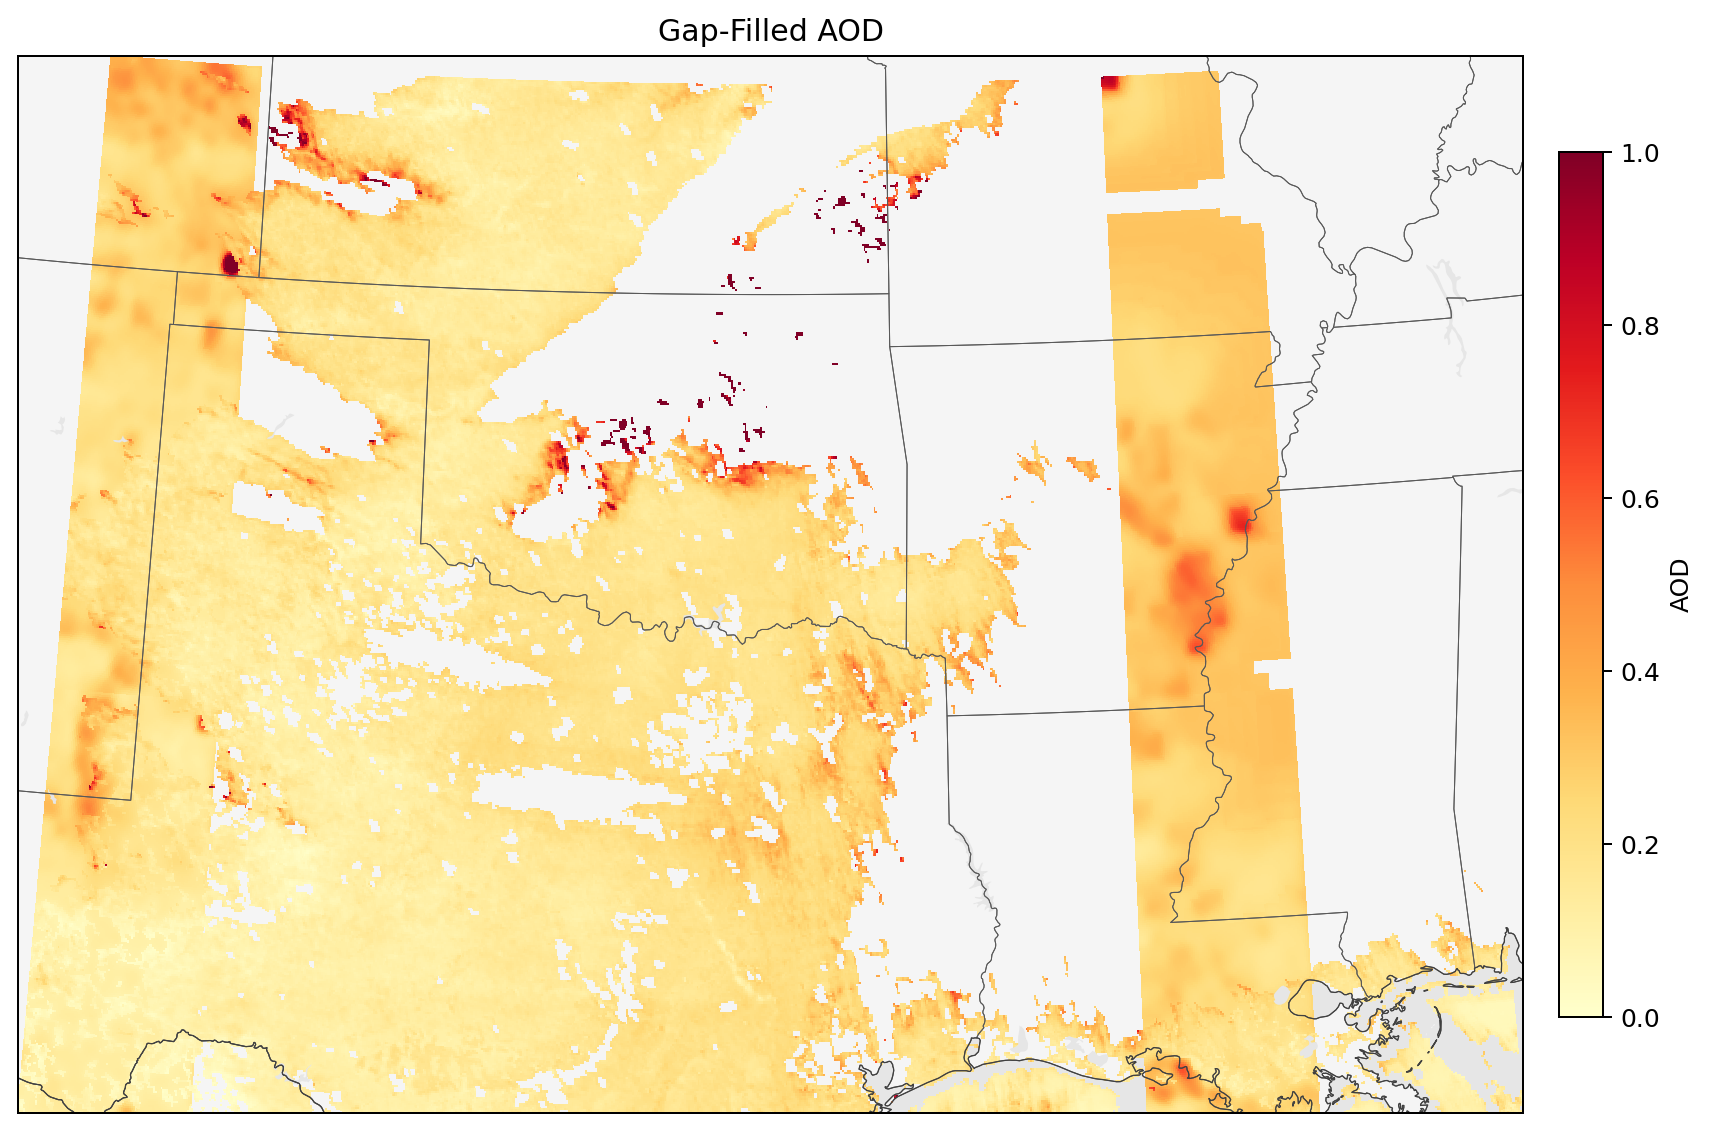

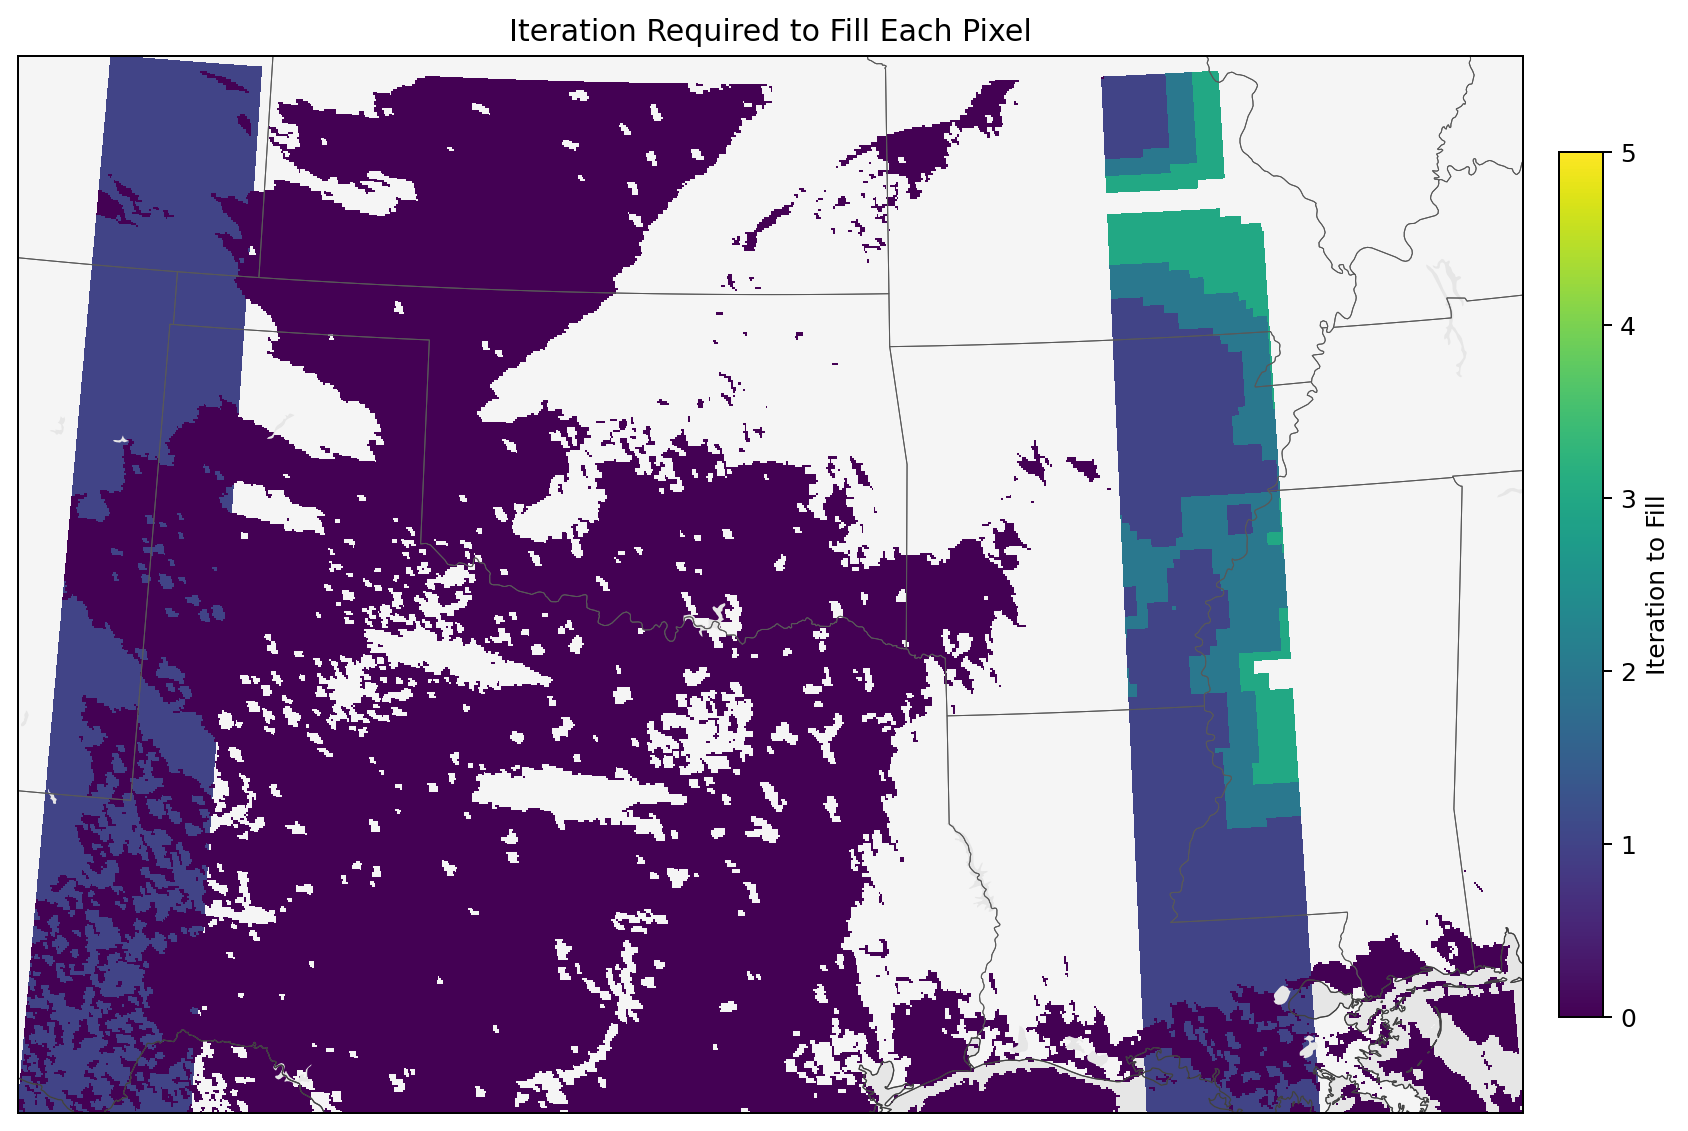

In [59]:
# load in files in case of timeout
final_sub_input = rioxarray.open_rasterio(f"{DATA_PATH_OUT}/PRED_36.tif")
final_sub_itert = rioxarray.open_rasterio(f"{DATA_PATH_OUT}/Iter_times_36.tif")

aod = np.ma.masked_less(final_sub_input[0].values, 0)
itn = np.ma.masked_less(final_sub_itert[0].values, 0)


x = final_sub_input.x.values
y = final_sub_input.y.values

def setup_map():
    fig, ax = plt.subplots(figsize=(13, 8), dpi=180,
                           subplot_kw={"projection": ccrs.LambertConformal()})
    ax.set_extent([x.min(), x.max(), y.min(), y.max()], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="0.96")
    ax.add_feature(cfeature.OCEAN, facecolor="0.90")
    ax.add_feature(cfeature.LAKES, facecolor="0.90")
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="0.35")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.25")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.25")
    return fig, ax

# AOD figure
fig, ax = setup_map()
m = ax.pcolormesh(
    x, y, aod,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    shading="auto",
    transform=ccrs.PlateCarree()
)
plt.colorbar(m, ax=ax, shrink=0.78, pad=0.02, label="AOD")
ax.set_title("Gap-Filled AOD")
plt.show()

# Iteration figure
fig, ax = setup_map()
m = ax.pcolormesh(
    x, y, itn,
    cmap="viridis",
    vmin=0, vmax=5,
    shading="auto",
    transform=ccrs.PlateCarree()
)
plt.colorbar(m, ax=ax, shrink=0.78, pad=0.02, label="Iteration to Fill")
ax.set_title("Iteration Required to Fill Each Pixel")
plt.show()